In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [3]:
df = pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\python\pyCourse\csvFiles\customer.csv')

In [11]:
df.head()

,age,gender,review,education,purchased
0,30,Female,Average,School,No
1,68,Female,Poor,UG,No
2,70,Female,Good,PG,No
3,72,Female,Good,PG,No
4,16,Female,Average,UG,No


In [5]:
#df.isnull().sum()

In [22]:
df.replace({'purchased': {'Yes':1,'No':0}}, inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_9764\3571535170.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'purchased': {'Yes':1,'No':0}}, inplace=True)


In [23]:
from sklearn.model_selection import train_test_split
x_tr, x_ts, y_tr, y_ts = train_test_split(df.drop(columns=['purchased'], axis=1), df['purchased'], test_size=0.2)

- Here: gender(nominal-OHE), review & eductn(ordinal-OrdinalEn), puchased(ordinal-Label-Target)

> Plan of Pipeline
- gender(OHE) -> review & edu(Ordinal) --> purchased(Label) -> Scaling(MinMax) -> Feature Selectn

In [1]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.feature_selection import SelectKBest,chi2
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer

In [8]:
# transformer for gender OHE
trf1 = ColumnTransformer(transformers=[
    ('gender_encoding', OneHotEncoder(drop='first', sparse_output=False),['gender'])
], remainder='passthrough')

In [24]:
# transformer for review & edu 
trf2 = ColumnTransformer(transformers=[
    ('review_edu_encoding', OrdinalEncoder(categories=[['Poor','Average','Good'],['School','UG','PG']]), ['review','education'],['review','purchased'])
], remainder='passthrough')

In [31]:
# transformer for scaling
trf4 = ColumnTransformer(transformers=[
    ('scale', MinMaxScaler(), slice(0,5))
], remainder='passthrough')

In [32]:
# transformer for selecting features
trf5 = SelectKBest(score_func='chi2', k=5)

In [33]:
# initialising model
trf6 = DecisionTreeClassifier()

- Making Pipeline

In [34]:
Pipe = Pipeline([
    ('trf1',trf1),
    ('trf2', trf2),
    ('trf4', trf4),
    ('trf5', trf5),
    ('trf6', trf6)
])

- Fitting data

In [15]:
df.head()

,age,gender,review,education,purchased
0,30,Female,Average,School,No
1,68,Female,Poor,UG,No
2,70,Female,Good,PG,No
3,72,Female,Good,PG,No
4,16,Female,Average,UG,No


C:\Users\HP\AppData\Local\Temp\ipykernel_9764\801968910.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_tr['age'])


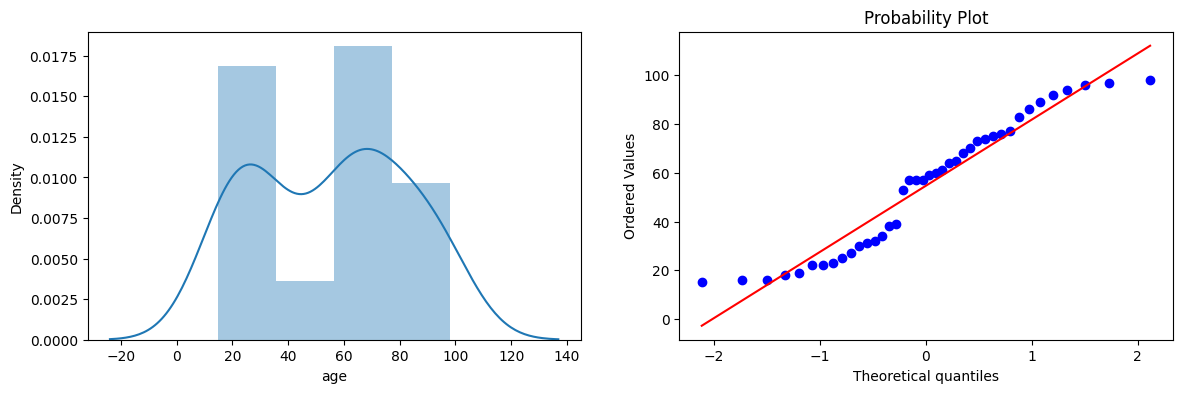

In [24]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(x_tr['age'])

plt.subplot(122)
stats.probplot(x_tr['age'], dist='norm', plot=plt)
plt.show()

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
lr = LogisticRegression()

lr.fit(x_tr, y_tr)

y_pred = lr.predict(x_ts)

print("Acc", accuracy_score(y_pred, y_ts))

ValueError: could not convert string to float: 'Male'